# Lab: Multi-class Classification

In this lab, you will build and compare two common strategies for multi-class classification: **One-vs-All (OvA)** and **One-vs-One (OvO)**. You will use a real-world obesity-level dataset and train logistic regression models to predict one of several obesity categories.

By the end of the lab, you should understand how to prepare mixed numerical and categorical data, avoid data leakage, train multi-class classifiers, and evaluate the results in a beginner-friendly workflow.


## Objectives

After completing this lab, you will be able to:

1. Explain the difference between binary and multi-class classification.
2. Prepare numerical and categorical features using scaling and one-hot encoding.
3. Split data before fitting preprocessing steps to avoid data leakage.
4. Train logistic regression with **One-vs-All (OvA)** and **One-vs-One (OvO)** strategies.
5. Evaluate multi-class classification models with accuracy, a classification report, and a confusion matrix.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

sns.set_theme(style='whitegrid', palette='Set2')


## About the Dataset

This lab uses the **Estimation of Obesity Levels Based on Eating Habits and Physical Condition** dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition). It contains 2,111 records and 17 columns.

The target column is `NObeyesdad`, which contains the obesity level category we want to predict.

| Column | Type | Meaning |
| --- | --- | --- |
| `Gender` | Categorical | Gender |
| `Age` | Numerical | Age |
| `Height` | Numerical | Height |
| `Weight` | Numerical | Weight |
| `family_history_with_overweight` | Binary categorical | Family history of overweight |
| `FAVC` | Binary categorical | Frequently eats high-calorie food |
| `FCVC` | Numerical | Frequency of vegetable consumption |
| `NCP` | Numerical | Number of main meals per day |
| `CAEC` | Categorical | Food consumption between meals |
| `SMOKE` | Binary categorical | Smoking status |
| `CH2O` | Numerical | Daily water consumption |
| `SCC` | Binary categorical | Monitors daily calories |
| `FAF` | Numerical | Physical activity frequency |
| `TUE` | Numerical | Time using technology devices |
| `CALC` | Categorical | Alcohol consumption frequency |
| `MTRANS` | Categorical | Main transportation method |
| `NObeyesdad` | Categorical target | Obesity level |


## 1. Load the Dataset

The CSV file is stored in the same folder as this notebook. The small fallback path below also lets the cell work when the notebook is run from the repository root.


In [2]:
DATA_PATH = Path('obesity_level_prediction_dataset.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('01-machine-learning-with-python/modules/03-building-supervised-learning-models/labs/obesity_level_prediction_dataset.csv')

data = pd.read_csv(DATA_PATH)
data.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Exploratory Data Analysis

Before training a model, inspect the dataset shape, columns, missing values, and target class distribution. This helps you understand what kind of preprocessing the data needs.


In [3]:
print(f'Rows: {data.shape[0]}')
print(f'Columns: {data.shape[1]}')

data.info()


Rows: 2111


Columns: 17


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [4]:
print('Missing values per column:')
data.isna().sum()


Missing values per column:


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [5]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


### Target Distribution

For a multi-class classification problem, check whether the target classes are reasonably balanced. A strongly imbalanced target may require extra techniques such as class weights, resampling, or additional metrics.


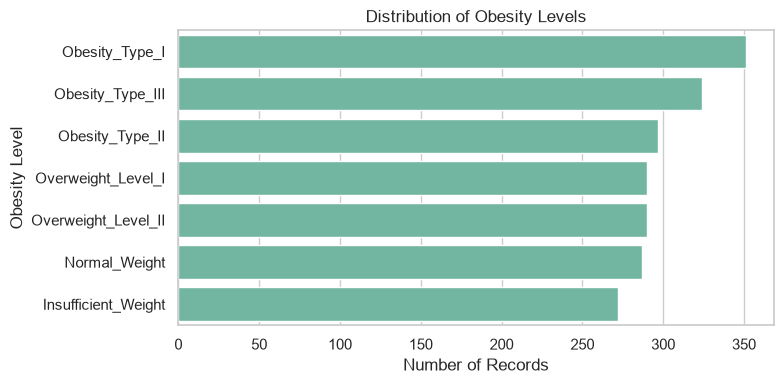

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, y='NObeyesdad', order=data['NObeyesdad'].value_counts().index)
plt.title('Distribution of Obesity Levels')
plt.xlabel('Number of Records')
plt.ylabel('Obesity Level')
plt.tight_layout()
plt.show()


In [7]:
class_distribution = data['NObeyesdad'].value_counts(normalize=True).mul(100).round(2)
class_distribution


NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: proportion, dtype: float64

The classes are not perfectly equal, but they are close enough for a first supervised learning lab. We will use a **stratified split** so the train and test sets keep approximately the same class proportions.


## 3. Split Features and Target

`X` contains the input features. `y` contains the target labels.

Because scikit-learn models expect numerical target values, we use `LabelEncoder` to convert each obesity category into an integer. We keep `class_names` so evaluation output can still show the original category names.


In [8]:
target_column = 'NObeyesdad'

X = data.drop(columns=target_column)
y_labels = data[target_column]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_

pd.DataFrame({
    'class_code': range(len(class_names)),
    'class_name': class_names
})


,class_code,class_name
0,0,Insufficient_Weight
1,1,Normal_Weight
2,2,Obesity_Type_I
3,3,Obesity_Type_II
4,4,Obesity_Type_III
5,5,Overweight_Level_I
6,6,Overweight_Level_II


## 4. Train/Test Split

Always split the data **before** fitting scalers or encoders. This prevents information from the test set from influencing the preprocessing steps during training.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training rows: {X_train.shape[0]}')
print(f'Testing rows: {X_test.shape[0]}')


Training rows: 1688


Testing rows: 423


## 5. Preprocessing Pipeline

The dataset contains both numerical and categorical columns:

- Numerical columns should be standardized with `StandardScaler`.
- Categorical columns should be converted to numbers with `OneHotEncoder`.

A `ColumnTransformer` lets us apply the correct preprocessing to each type of column. A `Pipeline` then combines preprocessing and model training into one repeatable workflow.


In [10]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = [column for column in X_train.columns if column not in numeric_features]

print('Numerical features:')
print(numeric_features)

print('\nCategorical features:')
print(categorical_features)


Numerical features:


['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


Categorical features:


['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [11]:
def make_one_hot_encoder():
    """Create a OneHotEncoder that works with recent and older scikit-learn versions."""
    try:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)


def build_preprocessor(numeric_columns, categorical_columns):
    return ColumnTransformer(
        transformers=[
            ('numeric', StandardScaler(), numeric_columns),
            ('categorical', make_one_hot_encoder(), categorical_columns),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def build_ova_model(numeric_columns, categorical_columns):
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(numeric_columns, categorical_columns)),
        ('classifier', OneVsRestClassifier(LogisticRegression(max_iter=1000)))
    ])


def build_ovo_model(numeric_columns, categorical_columns):
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(numeric_columns, categorical_columns)),
        ('classifier', OneVsOneClassifier(LogisticRegression(max_iter=1000)))
    ])


## 6. Strategy 1: One-vs-All (OvA)

In **One-vs-All**, also called **One-vs-Rest**, the model trains one binary classifier per class.

For example, if there are seven obesity levels, OvA trains seven binary classifiers:

- Class 0 vs all other classes
- Class 1 vs all other classes
- Class 2 vs all other classes
- and so on

During prediction, the class with the strongest confidence score is selected.


In [12]:
ova_model = build_ova_model(numeric_features, categorical_features)
ova_model.fit(X_train, y_train)

y_pred_ova = ova_model.predict(X_test)
ova_accuracy = accuracy_score(y_test, y_pred_ova)

print('One-vs-All (OvA) Logistic Regression')
print(f'Accuracy: {ova_accuracy:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_ova, target_names=class_names))


One-vs-All (OvA) Logistic Regression


Accuracy: 0.761


Classification report:


                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.96      0.93        54
      Normal_Weight       0.71      0.60      0.65        58
     Obesity_Type_I       0.63      0.74      0.68        70
    Obesity_Type_II       0.85      0.97      0.91        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.61      0.59      0.60        58
Overweight_Level_II       0.59      0.47      0.52        58

           accuracy                           0.76       423
          macro avg       0.76      0.76      0.75       423
       weighted avg       0.76      0.76      0.76       423


A confusion matrix shows where the model is making correct predictions and where it is confusing one class for another. The diagonal cells are correct predictions.


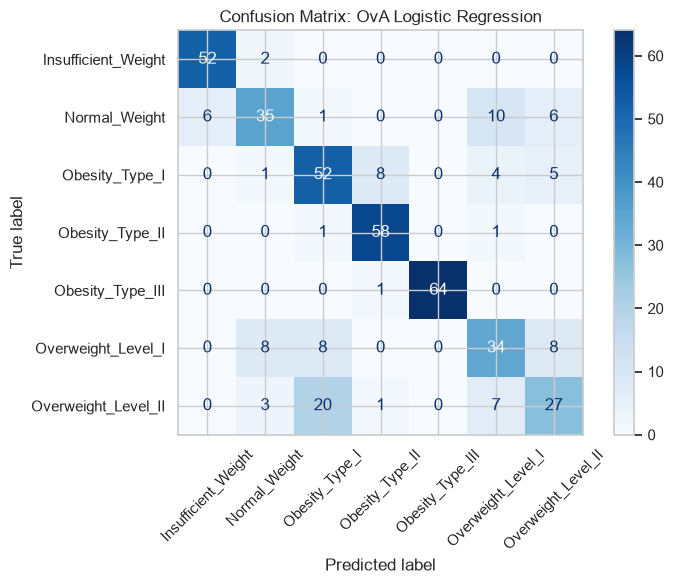

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ova,
    display_labels=class_names,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
plt.title('Confusion Matrix: OvA Logistic Regression')
plt.tight_layout()
plt.show()


## 7. Strategy 2: One-vs-One (OvO)

In **One-vs-One**, the model trains one binary classifier for every pair of classes.

If there are `k` classes, OvO trains:

$$\frac{k(k - 1)}{2}$$

binary classifiers. With seven classes, that means 21 pairwise classifiers. During prediction, each classifier votes, and the class with the most votes wins.


In [14]:
ovo_model = build_ovo_model(numeric_features, categorical_features)
ovo_model.fit(X_train, y_train)

y_pred_ovo = ovo_model.predict(X_test)
ovo_accuracy = accuracy_score(y_test, y_pred_ovo)

print('One-vs-One (OvO) Logistic Regression')
print(f'Accuracy: {ovo_accuracy:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_ovo, target_names=class_names))


One-vs-One (OvO) Logistic Regression


Accuracy: 0.924


Classification report:


                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.85      0.76      0.80        58
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.77      0.84      0.80        58
Overweight_Level_II       0.91      0.91      0.91        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.93      0.92      0.92       423


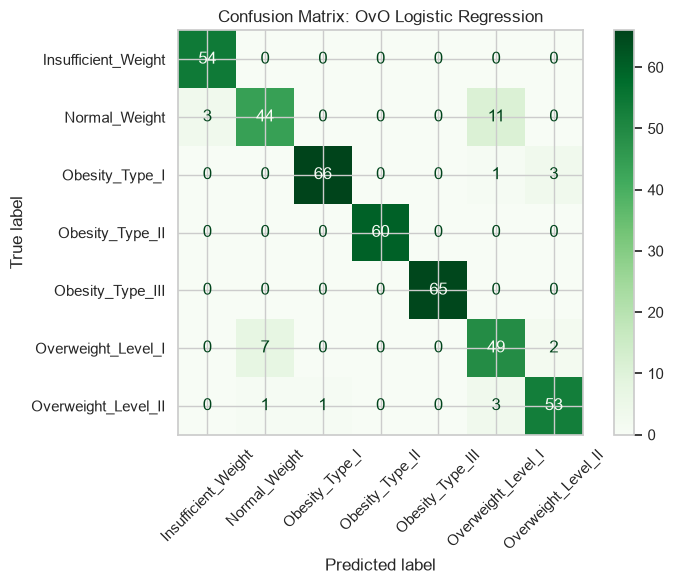

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ovo,
    display_labels=class_names,
    xticks_rotation=45,
    cmap='Greens',
    ax=ax
)
plt.title('Confusion Matrix: OvO Logistic Regression')
plt.tight_layout()
plt.show()


## 8. Compare the Strategies

Accuracy gives a quick comparison, but it should not be the only metric you use. The classification report is helpful because it shows precision, recall, and F1-score for each class.


In [16]:
comparison = pd.DataFrame({
    'strategy': ['One-vs-All (OvA)', 'One-vs-One (OvO)'],
    'accuracy': [ova_accuracy, ovo_accuracy]
})

comparison


,strategy,accuracy
0,One-vs-All (OvA),0.761229
1,One-vs-One (OvO),0.924350


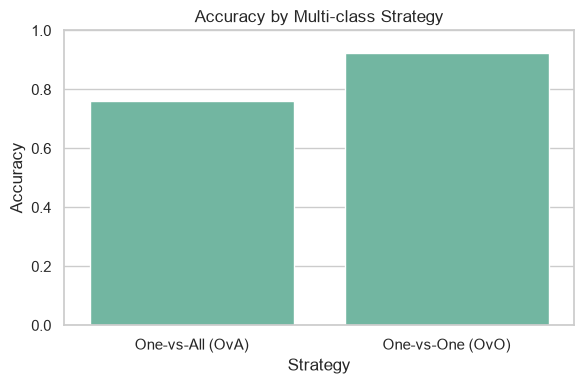

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x='strategy', y='accuracy')
plt.ylim(0, 1)
plt.title('Accuracy by Multi-class Strategy')
plt.xlabel('Strategy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


## 9. Exercises

### Exercise 1

Experiment with different `test_size` values such as `0.1`, `0.2`, and `0.3`. What happens to the accuracy when the test set becomes larger or smaller?


In [18]:
results = []

for test_size in [0.1, 0.2, 0.3]:
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    
    numeric_temp = X_train_temp.select_dtypes(include='number').columns.tolist()
    categorical_temp = [column for column in X_train_temp.columns if column not in numeric_temp]
    
    model = build_ova_model(numeric_temp, categorical_temp)
    model.fit(X_train_temp, y_train_temp)
    predictions = model.predict(X_test_temp)
    
    results.append({
        'test_size': test_size,
        'train_rows': X_train_temp.shape[0],
        'test_rows': X_test_temp.shape[0],
        'accuracy': accuracy_score(y_test_temp, predictions)
    })

pd.DataFrame(results)


,test_size,train_rows,test_rows,accuracy
0,0.1,1899,212,0.759434
1,0.2,1688,423,0.761229
2,0.3,1477,634,0.749211


### Exercise 2

Plot the most important features for each strategy using the absolute values of the logistic regression coefficients. Larger absolute coefficient values usually mean the model relied more heavily on that feature.

For readability, plot only the top 15 features.


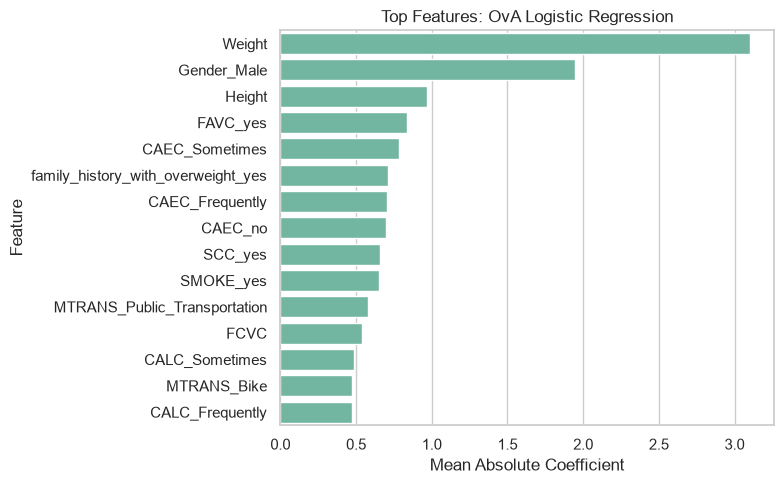

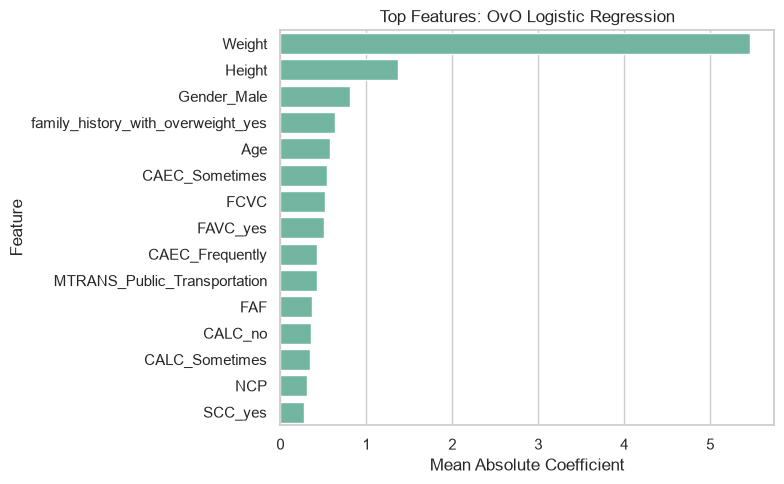

In [19]:
def plot_top_coefficients(model, title, top_n=15):
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    classifier = model.named_steps['classifier']
    
    if isinstance(classifier, OneVsRestClassifier):
        coefficients = np.array([estimator.coef_[0] for estimator in classifier.estimators_])
    else:
        coefficients = np.array([estimator.coef_[0] for estimator in classifier.estimators_])
    
    importance = np.mean(np.abs(coefficients), axis=0)
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='importance', y='feature')
    plt.title(title)
    plt.xlabel('Mean Absolute Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_top_coefficients(ova_model, 'Top Features: OvA Logistic Regression')
plot_top_coefficients(ovo_model, 'Top Features: OvO Logistic Regression')


### Exercise 3

Create a function named `obesity_risk_pipeline` that automates the full workflow:

1. Load the dataset.
2. Encode the target labels.
3. Split the data.
4. Build the preprocessing and model pipeline.
5. Train and evaluate the model.

The function should accept a file path, test size, and strategy (`'ova'` or `'ovo'`).


In [20]:
def obesity_risk_pipeline(data_path, test_size=0.2, strategy='ova'):
    data = pd.read_csv(data_path)
    
    X = data.drop(columns='NObeyesdad')
    y_labels = data['NObeyesdad']
    
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_labels)
    class_names = label_encoder.classes_
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    
    numeric_features = X_train.select_dtypes(include='number').columns.tolist()
    categorical_features = [column for column in X_train.columns if column not in numeric_features]
    
    if strategy.lower() == 'ova':
        model = build_ova_model(numeric_features, categorical_features)
        strategy_name = 'One-vs-All (OvA)'
    elif strategy.lower() == 'ovo':
        model = build_ovo_model(numeric_features, categorical_features)
        strategy_name = 'One-vs-One (OvO)'
    else:
        raise ValueError("strategy must be either 'ova' or 'ovo'")
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    
    print(f'{strategy_name} Logistic Regression')
    print(f'Test size: {test_size}')
    print(f'Accuracy: {accuracy:.3f}')
    print('\nClassification report:')
    print(classification_report(y_test, predictions, target_names=class_names))
    
    return model

trained_model = obesity_risk_pipeline(DATA_PATH, test_size=0.2, strategy='ova')


One-vs-All (OvA) Logistic Regression


Test size: 0.2


Accuracy: 0.761


Classification report:


                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.96      0.93        54
      Normal_Weight       0.71      0.60      0.65        58
     Obesity_Type_I       0.63      0.74      0.68        70
    Obesity_Type_II       0.85      0.97      0.91        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.61      0.59      0.60        58
Overweight_Level_II       0.59      0.47      0.52        58

           accuracy                           0.76       423
          macro avg       0.76      0.76      0.75       423
       weighted avg       0.76      0.76      0.76       423


## Key Takeaways

- Multi-class classification predicts one label from three or more possible classes.
- OvA trains one classifier per class; OvO trains one classifier per pair of classes.
- Fit preprocessing steps only on the training data to avoid data leakage.
- Accuracy is useful, but precision, recall, F1-score, and confusion matrices give a more complete picture of model performance.
- Pipelines make machine learning workflows easier to reuse and less error-prone.
